# Visualize generated pointcloud trajectories

Loads the `.pt` file written by `generate_trajectories.py` and renders 3D molecules + trajectory animations.

In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path
from collections import Counter

import numpy as np
import torch
from IPython.display import display
from rdkit import Chem


def find_repo_root(start: Path) -> Path:
    cur = start.resolve()
    for candidate in [cur, *cur.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Could not locate repository root")


PROJECT_ROOT = find_repo_root(Path.cwd())
for p in [str(PROJECT_ROOT), str(PROJECT_ROOT / "src")]:
    if p not in sys.path:
        sys.path.insert(0, p)
os.environ.setdefault("PROJECT_ROOT", str(PROJECT_ROOT))
print(f"PROJECT_ROOT={PROJECT_ROOT}")

PROJECT_ROOT=/network/scratch/g/goldszaa/chemflow


In [2]:
# Path to the .pt produced by generate_trajectories.py
TRAJ_PATH = PROJECT_ROOT / "src" / "chemflow" / "rl" / "experiments" / "pointcloud_viz" / "trajectories.pt"

blob = torch.load(str(TRAJ_PATH), weights_only=False)
records = blob["records"]

print(f"Loaded: {TRAJ_PATH}")
print(f"ckpt:           {blob.get('ckpt')}")
print(f"representation: {blob.get('representation')}")
print(f"n_requested:    {blob.get('n_mols_requested')}")
print(f"n_generated:    {blob.get('n_generated')}")
print(f"records:        {len(records)}")


/home/mila/g/goldszaa/scratch/chemflow/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded: /network/scratch/g/goldszaa/chemflow/experiments/pointcloud_viz/trajectories.pt
ckpt:           /home/mila/g/goldszaa/scratch/chemflow/outputs/qm9/grpo/2026-05-21/mla55y9e/grpo_best.pt
representation: pointcloud
n_requested:    200
n_generated:    200
records:        200


In [3]:
# Atom-count stats over all generated pointclouds
atom_counts = np.array([int(r["final_n_atoms"]) for r in records], dtype=int)
if atom_counts.size:
    print(f"n_records={atom_counts.size}")
    print(f"mean={atom_counts.mean():.2f}  median={np.median(atom_counts):.1f}  "
          f"min={atom_counts.min()}  max={atom_counts.max()}")
    print("\nTop atom counts:")
    for n, c in sorted(Counter(atom_counts.tolist()).items(), key=lambda kv: (-kv[1], -kv[0]))[:15]:
        print(f"  n_atoms={n:>3} -> {c}")
else:
    print("No records.")


n_records=200
mean=80.74  median=81.0  min=49  max=92

Top atom counts:
  n_atoms= 83 -> 28
  n_atoms= 81 -> 19
  n_atoms= 80 -> 18
  n_atoms= 84 -> 17
  n_atoms= 82 -> 17
  n_atoms= 79 -> 16
  n_atoms= 85 -> 13
  n_atoms= 78 -> 13
  n_atoms= 87 -> 9
  n_atoms= 77 -> 9
  n_atoms= 88 -> 7
  n_atoms= 75 -> 7
  n_atoms= 76 -> 5
  n_atoms= 74 -> 5
  n_atoms= 86 -> 4


## Steric clashes (min pairwise distance < 0.5 Å)

MinDistanceViolation (frac mols with min-dist < 0.5 Å): 199/200 = 99.5%
min pairwise dist over all mols: min=0.006  median=0.243  max=0.514


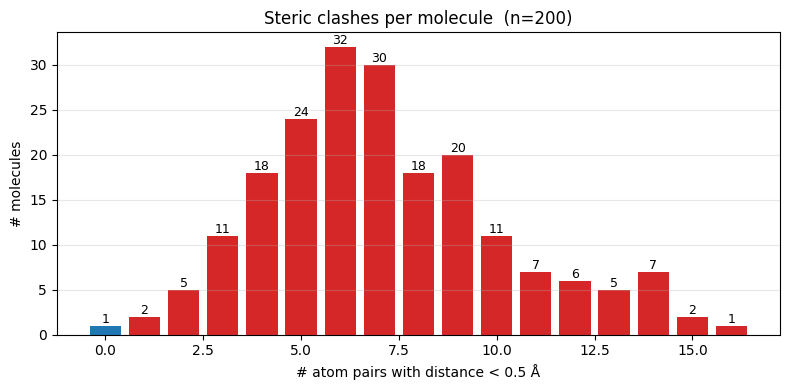

In [8]:
import torch
import matplotlib.pyplot as plt

# Matches src/chemflow/utils/metrics/tensor.py MinDistanceViolation (threshold=0.5 Å).
THRESHOLD = 0.5

clash_counts = []   # # atom pairs below threshold, per molecule
min_dists = []      # min pairwise distance, per molecule
for rec in records:
    frame = rec["trajectory"][-1]
    n = int(frame.num_nodes)
    if n < 2:
        clash_counts.append(0); min_dists.append(float("nan")); continue
    coord = frame.x[:n].detach().cpu()
    i, j = torch.triu_indices(n, n, offset=1)
    d = (coord[i] - coord[j]).norm(dim=-1)
    clash_counts.append(int((d < THRESHOLD).sum().item()))
    min_dists.append(float(d.min().item()))

n_violating = sum(c > 0 for c in clash_counts)
print(f"MinDistanceViolation (frac mols with min-dist < {THRESHOLD} Å): "
      f"{n_violating}/{len(records)} = {n_violating/len(records):.1%}")
print(f"min pairwise dist over all mols: "
      f"min={min(min_dists):.3f}  median={sorted(min_dists)[len(min_dists)//2]:.3f}  max={max(min_dists):.3f}")

# Histogram: x = # clashes per molecule, y = # molecules
from collections import Counter
ctr = Counter(clash_counts)
xs = sorted(ctr)
ys = [ctr[x] for x in xs]
plt.figure(figsize=(8, 4))
bars = plt.bar(xs, ys, color=["#1f77b4" if x == 0 else "#d62728" for x in xs])
plt.xlabel(f"# atom pairs with distance < {THRESHOLD} Å")
plt.ylabel("# molecules")
plt.title(f"Steric clashes per molecule  (n={len(records)})")
for b, y in zip(bars, ys):
    plt.text(b.get_x() + b.get_width()/2, y, str(y), ha="center", va="bottom", fontsize=9)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout(); plt.show()


In [4]:
# Build vocab so we can convert frames -> RDKit / 3D viz input
import hydra
from chemflow.rl.run_grpo import compose_cfg

cfg = compose_cfg(str(PROJECT_ROOT / "configs"), "default",
                  overrides=blob.get("hydra_overrides", []))
preprocessing = hydra.utils.instantiate(cfg.data.preprocessing)
vocab = preprocessing.vocab


## Atom composition (pointclouds have no bonds)

In [5]:
from collections import Counter

# Aggregate atom symbols across all generated pointclouds
all_syms = []
per_mol_syms = []
for rec in records:
    frame = rec["trajectory"][-1]
    n = int(frame.num_nodes)
    syms = [vocab.atom_tokens[int(i)] for i in frame.a.detach().cpu().reshape(-1)[:n].tolist()]
    all_syms.extend(syms)
    per_mol_syms.append(Counter(syms))

print(f"Total atoms across {len(records)} mols: {len(all_syms)}")
print("\nAtom-type frequencies (global):")
for sym, c in Counter(all_syms).most_common():
    print(f"  {sym:>4} : {c:>6}  ({100*c/len(all_syms):.1f}%)")

print("\nFirst 10 molecules (formula):")
for i, ctr in enumerate(per_mol_syms[:10]):
    formula = " ".join(f"{s}{n}" for s, n in sorted(ctr.items()))
    print(f"  #{i:>2} n={sum(ctr.values()):>3}  {formula}")


Total atoms across 200 mols: 16148

Atom-type frequencies (global):
     H :  11698  (72.4%)
     C :   4334  (26.8%)
     O :     77  (0.5%)
     N :     39  (0.2%)

First 10 molecules (formula):
  # 0 n= 77  C22 H55
  # 1 n= 86  C24 H62
  # 2 n= 80  C19 H61
  # 3 n= 79  C23 H55 N1
  # 4 n= 79  C23 H55 O1
  # 5 n= 82  C20 H62
  # 6 n= 85  C21 H64
  # 7 n= 89  C24 H64 O1
  # 8 n= 83  C18 H64 O1
  # 9 n= 80  C20 H59 N1


## 3D grid of final molecules

In [6]:
from notebooks.utils import process_mol, visualize_mols_grid

TOP_K_3D = 24
NUM_COLS_3D = 6

selected = sorted(records, key=lambda r: int(r["final_n_atoms"]), reverse=True)[:TOP_K_3D]
frames = [
    process_mol(r["trajectory"][-1], vocab.atom_tokens, vocab.charge_tokens, vocab.edge_tokens)
    for r in selected
]
view = visualize_mols_grid(frames, width=1200, height=720, num_cols=NUM_COLS_3D, gap=4.0)
view.show()


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Animated trajectory

Trajectory #0: 100 frames, final_n_atoms=77


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

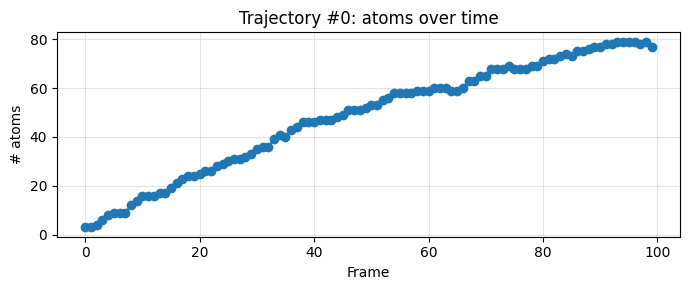

In [7]:
import matplotlib.pyplot as plt
from notebooks.utils import process_mol, visualize_variable_topology

traj_idx = 0  # pick which record to animate
rec = records[traj_idx]
traj_frames = [
    process_mol(f, vocab.atom_tokens, vocab.charge_tokens, vocab.edge_tokens)
    for f in rec["trajectory"]
]
print(f"Trajectory #{traj_idx}: {len(traj_frames)} frames, final_n_atoms={int(rec['final_n_atoms'])}")
view = visualize_variable_topology(traj_frames, width=950, height=460, interval=50)
view.show()

n_per_frame = [len(f["atoms"]) for f in traj_frames]
plt.figure(figsize=(7, 3))
plt.plot(n_per_frame, marker="o", linewidth=1.5)
plt.title(f"Trajectory #{traj_idx}: atoms over time")
plt.xlabel("Frame"); plt.ylabel("# atoms"); plt.grid(True, alpha=0.35); plt.tight_layout()
plt.show()
